# Test of Time-dependent Dissipative Dynamics

The purpose of this notebook is to test and visually verify the correct implementation of dynamics with time-dependent dissipators. We look at a single qubit, driven by a GKSL generator with a single discrete time dependent dissipator that flips between pumping and dissipating dynamics periodically.

## 1. Imports

In [1]:
from qsim.dynamics import GKSLGenerator, RK4Propagator, Dynamics
from qsim.logging import Logger
from qsim.lin_alg import sigmaMinus, sigmaPlus, I, TOperator, sigmaZ, sigmaX
from qsim.state import ObservableDetector, DensityMatrix
from tqdm.auto import tqdm
import numpy as np

import math
import matplotlib.pyplot as plt

/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configure Dynamics

In [2]:
# System dimension
d = 4

# Dynamic switch frequency
omega = 3

In [3]:
f1 = (lambda t: math.floor((t/omega)%2))
f2 = (lambda t: 1 - math.floor((t/omega)%2))

Text(0.5, 1.0, 'Periodic Driving Function')

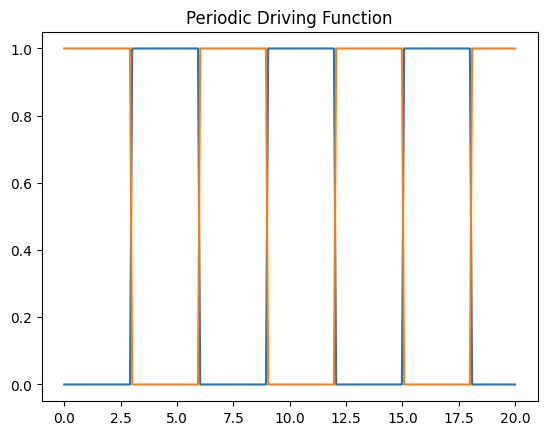

In [4]:
ts = np.linspace(0, 20, 200)
plt.plot(ts, list(map(f1, ts)))
plt.plot(ts, list(map(f2, ts)))
plt.title('Periodic Driving Function')

In [5]:
H = sigmaX.tensor(sigmaX)
L1 =  f2 * TOperator.from_static(sigmaMinus) + f1  * TOperator.from_static(sigmaPlus)
L2 =  f1*  TOperator.from_static(sigmaMinus) +  f2 * TOperator.from_static(sigmaPlus)

In [6]:
L1_embedded = L1.changeHilbertSpace((2,2), (0,))
L2_embedded = L2.changeHilbertSpace((2,2), (1,))

In [7]:
def warnIfIllegitimate(state, t):
    if not state.isLegitimate():
        print(f'Illegitimate State at t={t}')

## 3. Logger Setup

In [8]:
detector_qubit1 = ObservableDetector(sigmaZ, dims=(2,2), target_sites=(0,))
detector_qubit2 = ObservableDetector(sigmaZ, dims=(2,2), target_sites=(1,))

detector_joint = ObservableDetector(sigmaZ.tensor(sigmaZ))

In [9]:
logger_composite = Logger([detector_qubit1, detector_qubit2, detector_joint])

In [10]:
generator = GKSLGenerator(H=H, jumps=[L1_embedded, L2_embedded])
propagator = RK4Propagator(ts=0.01)#, callbacks=[])

In [11]:
dynamics = Dynamics(propagator, generator)
dynamics.addCallback(logger_composite.log)

## 4. Evolution

In [12]:
initial_state = DensityMatrix(np.array([[0,0,0,0],[0,1,0,0],[0,0,0,0],[0,0,0,0]]))

import cProfile

# 1. WARM-UP RUN
# Run the simulation for a tiny amount of time (e.g., 1 or 2 steps).
# This forces Numba to compile all the math kernels.
print("Compiling...")
dynamics.evolve(initial_state, ts=list(ts[:2]))

# 2. THE REAL TEST
# Now that the machine code is cached, run the real simulation
# and start the profiler.
print("Running simulation...")
profiler = cProfile.Profile()
profiler.enable()

# Run your actual, full-length simulation here
dynamics.evolve(initial_state, ts=list(ts[2:]))

profiler.disable()
profiler.print_stats(sort='cumtime')

In [13]:
import time
s = time.time()
#traj = propagator.evolve(generator, initial_state, ts[-1])
dynamics.evolve(initial_state, ts=list(ts))
time.time() - s

3.652144193649292

## 5. Visualisation

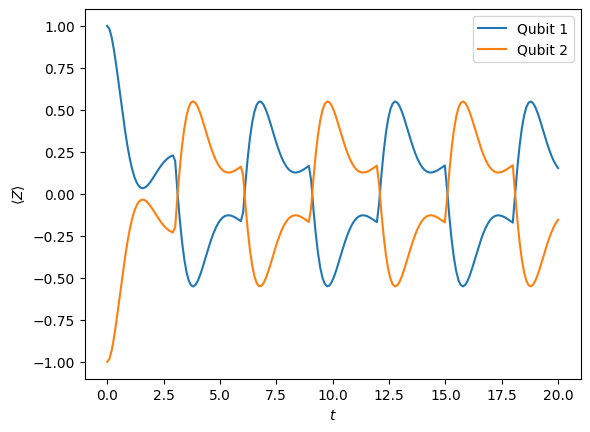

In [14]:
plt.plot(ts, logger_composite.observable_log[detector_qubit1].values(), label='Qubit 1')
plt.plot(ts, logger_composite.observable_log[detector_qubit2].values(), label = 'Qubit 2')
#plt.plot(ts, logger_composite.observable_log[detector_joint].values(), label = 'Joint')
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')
plt.legend()

## 6. Heisenberg Evolution

In [15]:
generator = GKSLGenerator(H=H, jumps=[L1_embedded, L2_embedded])
propagator = RK4Propagator(ts=0.01)

In [16]:
heisenberg_dynamics = Dynamics(propagator, generator)

In [17]:
reduced_ts = ts
ops1 = [heisenberg_dynamics.evolveOperator(sigmaZ.tensor(I(2)), ts=[0], t0=t) for t in tqdm(reduced_ts)]
ops2 = [heisenberg_dynamics.evolveOperator(I(2).tensor(sigmaZ), ts=[0], t0=t) for t in tqdm(reduced_ts)]

100%|██████████| 200/200 [00:01<00:00, 102.48it/s]


In [18]:
initial_state = DensityMatrix(np.array([[0,0,0,0],[0,1,0,0],[0,0,0,0],[0,0,0,0]]))

/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/matthewmackinnon/Documents/repos/QSim/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


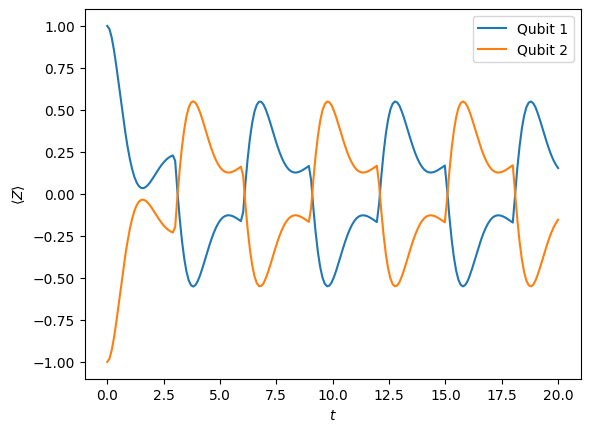

In [19]:
plt.plot(reduced_ts, [(op @ initial_state).trace() for op in ops1], label='Qubit 1')
plt.plot(reduced_ts, [(op @ initial_state).trace() for op in ops2], label='Qubit 2')
#plt.plot(ts, logger_composite.observable_log[detector_joint].values(), label = 'Joint')
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')
plt.legend()